In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os


In [2]:
os.listdir("../input/osic-pulmonary-fibrosis-progression")


['train.csv',
 'sample_submission.csv',
 'test',
 'sample_submission.csv.zip',
 'test.csv',
 'test.csv.zip',
 'train.csv.zip',
 'osic-pulmonary-fibrosis-progression',
 'train.zip',
 'test.zip',
 'description.md',
 'train']

In [3]:
train = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/train.csv")
test = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/test.csv")


In [4]:
train.head()


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked


In [5]:
test.head()


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker


In [6]:
submission = pd.read_csv("../input/osic-pulmonary-fibrosis-progression/sample_submission.csv")


In [7]:
submission.head()


,Patient_Week,FVC,Confidence
0,ID00126637202218610655908_-3,2000,100
1,ID00126637202218610655908_-2,2000,100
2,ID00126637202218610655908_-1,2000,100
3,ID00126637202218610655908_0,2000,100
4,ID00126637202218610655908_1,2000,100


In [8]:
print(f"Train info {train.shape}")
print(f"test info {test.shape}")
print(f"submission info {submission.shape}")


Train info (1394, 7)
test info (18, 7)
submission info (1908, 3)


In [9]:
import pydicom
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
print(f"Total Patient Id {train['Patient'].count()}")
print(f"NUmber of Unique Id {train['Patient'].value_counts().shape[0]}")


Total Patient Id 1394
NUmber of Unique Id 158


<Axes: xlabel='SmokingStatus'>

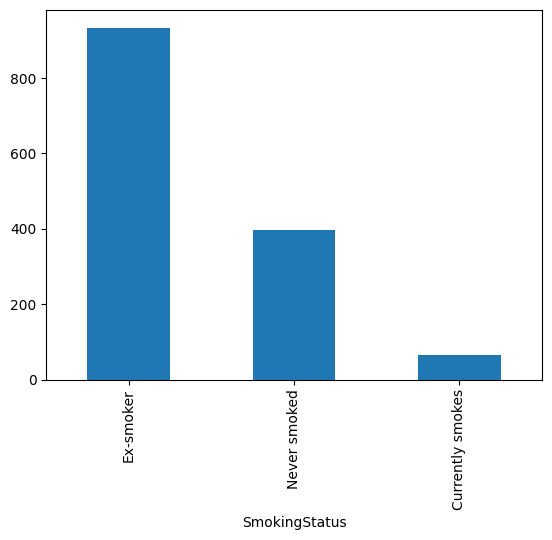

In [11]:
train["SmokingStatus"].value_counts().plot(kind="bar")


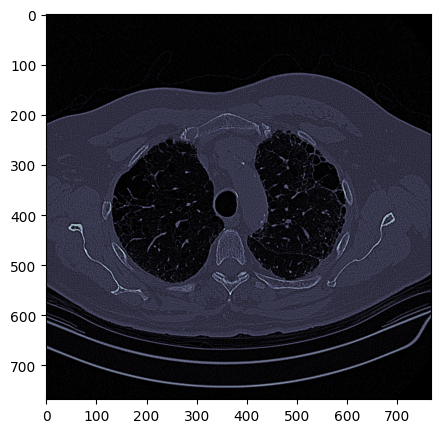

In [12]:
img = "../input/osic-pulmonary-fibrosis-progression/train/ID00009637202177434476278/100.dcm"
ds = pydicom.dcmread(img)
plt.figure(figsize = (5,5))
plt.imshow(ds.pixel_array, cmap=plt.cm.bone)


In [13]:
import random


def get_random(smokes):
    smoke_pat = train[train["SmokingStatus"]==smokes] 
    patientz = [i for i in smoke_pat["Patient"]] # patient id list
    r_st = random.choice(patientz) # random choice
    print(r_st)
    image_dir = f"../input/osic-pulmonary-fibrosis-progression/train/{r_st}" # image directory
    image_list = os.listdir(image_dir) # list of images
    c = []
    for t in image_list:
        first, exts = os.path.splitext(t) # split text
        first = int(first) # int
        c.append(first) # append
    d = [num for num in range(1, 31)] # num from 1 to 30
    gh = []
    for x in c:
        if x in d:
            gh.append(x) # if number is in list then append
    fig = plt.figure(figsize=(10, 10)) # figure
    columns = 5
    row = 6
    for ab in gh:
        files = image_dir + "/" + str(ab) + ".dcm" # file directory
        ds = pydicom.dcmread(files) # read dcm file
        fig.add_subplot(row, columns, ab) # add plot
        plt.imshow(ds.pixel_array, cmap=plt.cm.bone) # show images
    plt.suptitle(smokes) # title


ID00165637202237320314458


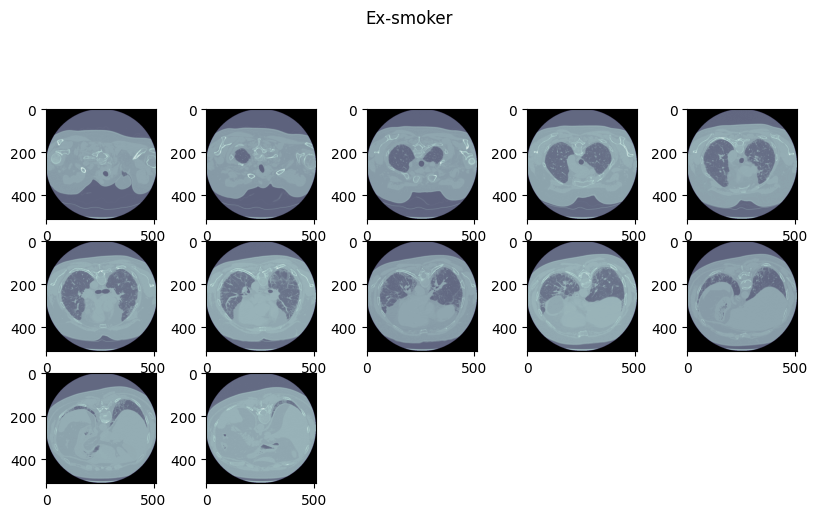

In [14]:
get_random("Ex-smoker")


In [15]:
# train.drop_duplicates(keep=False, inplace=True, subset=["Patient", "Weeks"])


In [16]:
submission["Patient"] = submission["Patient_Week"].apply(lambda x:x.split("_")[0])
submission["Weeks"] = submission["Patient_Week"].apply(lambda x:x.split("_")[1])

submission =  submission[['Patient','Weeks', 'Confidence','Patient_Week']]
submission = submission.merge(test.drop('Weeks', axis=1), on="Patient")


In [17]:
submission.tail()


,Patient,Weeks,Confidence,Patient_Week,FVC,Percent,Age,Sex,SmokingStatus
1903,ID00047637202184938901501,98,100,ID00047637202184938901501_98,3313,89.929425,68,Male,Ex-smoker
1904,ID00047637202184938901501,99,100,ID00047637202184938901501_99,3313,89.929425,68,Male,Ex-smoker
1905,ID00047637202184938901501,100,100,ID00047637202184938901501_100,3313,89.929425,68,Male,Ex-smoker
1906,ID00047637202184938901501,101,100,ID00047637202184938901501_101,3313,89.929425,68,Male,Ex-smoker
1907,ID00047637202184938901501,102,100,ID00047637202184938901501_102,3313,89.929425,68,Male,Ex-smoker


In [18]:
submission.shape


(1908, 9)

In [19]:
train.head()


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked


In [20]:
test


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker
5,ID00127637202219096738943,44,1677,65.855095,55,Female,Ex-smoker
6,ID00135637202224630271439,31,3808,106.096066,65,Male,Never smoked
7,ID00213637202257692916109,6,3035,83.562775,70,Male,Currently smokes
8,ID00219637202258203123958,0,6399,153.012912,71,Male,Ex-smoker
9,ID00225637202259339837603,13,1583,80.172195,77,Female,Never smoked


In [21]:
sns.heatmap(train.corr(), annot=True)


ValueError: could not convert string to float: 'ID00133637202223847701934'

In [22]:
test


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker
5,ID00127637202219096738943,44,1677,65.855095,55,Female,Ex-smoker
6,ID00135637202224630271439,31,3808,106.096066,65,Male,Never smoked
7,ID00213637202257692916109,6,3035,83.562775,70,Male,Currently smokes
8,ID00219637202258203123958,0,6399,153.012912,71,Male,Ex-smoker
9,ID00225637202259339837603,13,1583,80.172195,77,Female,Never smoked


In [23]:
submission["Patient"].unique()


array(['ID00126637202218610655908', 'ID00364637202296074419422',
       'ID00135637202224630271439', 'ID00127637202219096738943',
       'ID00294637202279614924243', 'ID00233637202260580149633',
       'ID00019637202178323708467', 'ID00383637202300493233675',
       'ID00317637202283194142136', 'ID00213637202257692916109',
       'ID00339637202287377736231', 'ID00344637202287684217717',
       'ID00014637202177757139317', 'ID00225637202259339837603',
       'ID00407637202308788732304', 'ID00219637202258203123958',
       'ID00082637202201836229724', 'ID00047637202184938901501'],
      dtype=object)

In [24]:
train.shape


(1394, 7)

In [25]:
train["Dataset"] = "train"
test["Dataset"] = "test"
submission["Dataset"] = "submission"


In [26]:
dataset = train.append([test, submission])
dataset = dataset.reset_index()
dataset = dataset.drop(columns=['index'])


AttributeError: 'DataFrame' object has no attribute 'append'

In [27]:
dataset.head()


NameError: name 'dataset' is not defined

In [28]:
dataset["Weeks"] = dataset["Weeks"].astype("int64")


NameError: name 'dataset' is not defined

In [29]:
dataset.info()


NameError: name 'dataset' is not defined

In [30]:
dataset["First_week"] = dataset["Weeks"]
dataset.loc[dataset.Dataset=='submission','First_week'] = np.nan
dataset["First_week"] = dataset.groupby('Patient')['First_week'].transform('min')


NameError: name 'dataset' is not defined

In [31]:
dataset.head()


NameError: name 'dataset' is not defined

In [32]:
dataset = dataset.merge(dataset[dataset["Weeks"] == dataset["First_week"]][["Patient", "FVC"]].rename({"FVC": "First_FVC"}, axis=1).groupby("Patient").first().reset_index(), on="Patient", how="left")


NameError: name 'dataset' is not defined

In [33]:
dataset["Week_diff"] = dataset["Weeks"] - dataset["First_week"]
# dataset["FVC_diff"] = dataset["First_FVC"] - dataset["FVC"]

dataset = pd.concat([dataset,pd.get_dummies(dataset.Sex),pd.get_dummies(dataset.SmokingStatus)], axis=1)

dataset = dataset.drop(columns=['Sex', 'SmokingStatus'])


NameError: name 'dataset' is not defined

In [34]:
dataset.tail()


NameError: name 'dataset' is not defined

In [35]:
dataset.info()


NameError: name 'dataset' is not defined

In [36]:
train = dataset[dataset["Dataset"]=="train"]
test = dataset[dataset["Dataset"]=="test"]
submission = dataset[dataset["Dataset"]=="submission"]


NameError: name 'dataset' is not defined

In [37]:
from sklearn.preprocessing import StandardScaler

col = ['Weeks', 'Percent', 'Age', 'First_week', 'First_FVC', 'Week_diff',
       'Female', 'Male', 'Currently smokes', 'Ex-smoker', 'Never smoked']

train_data = train[col]


KeyError: "['First_week', 'First_FVC', 'Week_diff', 'Female', 'Male', 'Currently smokes', 'Ex-smoker', 'Never smoked'] not in index"

In [38]:
train_data.isnull().any()


NameError: name 'train_data' is not defined

ValueError: could not convert string to float: 'ID00133637202223847701934'

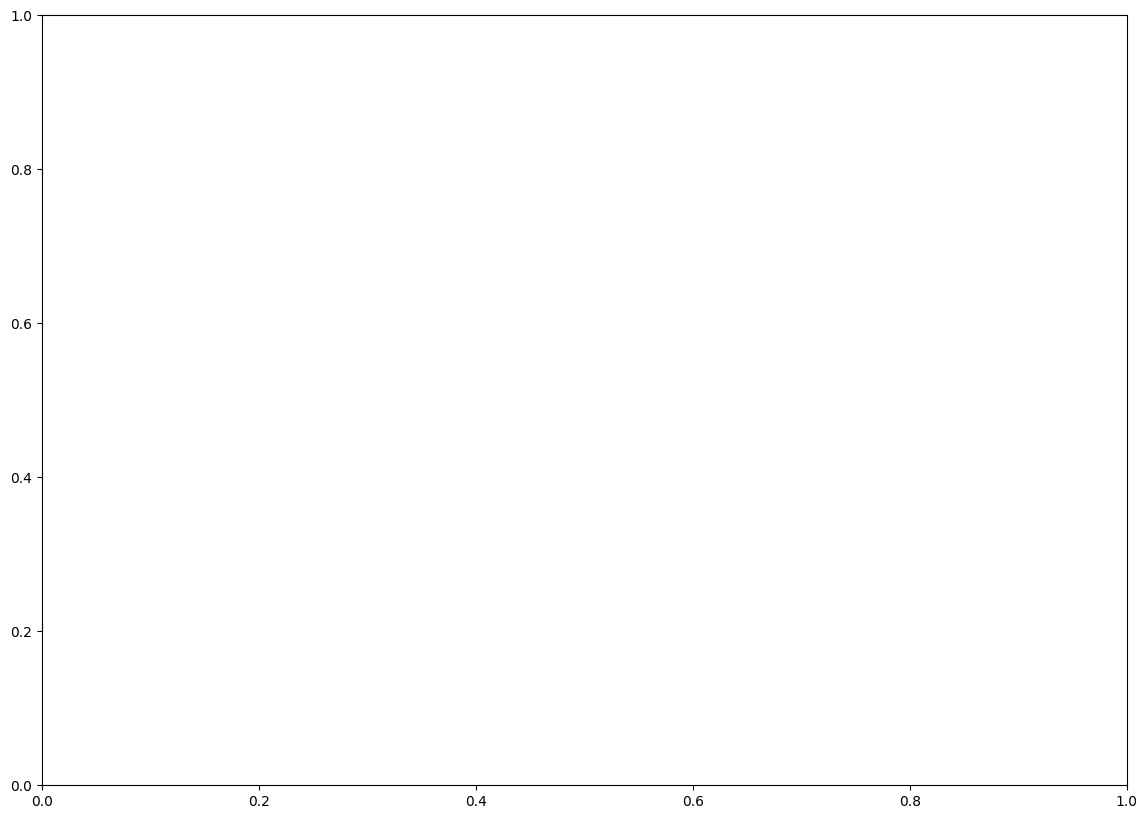

In [39]:
plt.subplots(figsize=(14,10))
g = train.corr()
sns.heatmap(g, annot=True, fmt='.2', cmap="Dark2_r")


In [40]:
g["FVC"].sort_values(ascending=False)


NameError: name 'g' is not defined

In [41]:
stdscale = StandardScaler()
train_data[col] = stdscale.fit_transform(train_data[col])


NameError: name 'train_data' is not defined

In [42]:
train_data[col]


NameError: name 'train_data' is not defined

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


In [44]:
model_params = {
    "svr": {
        "model": SVR(),
        "params": {
            "C": [1, 10, 20],
            "kernel":['linear', 'poly', 'rbf', 'sigmoid']
        }
    },
    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators":[100, 200]
        }
    },
    "LR": {
        "model": LinearRegression(),
        "params": {}
    }
}


In [45]:
from sklearn.model_selection import GridSearchCV
scores = []
for model_name, param in model_params.items():
    clf = GridSearchCV(param["model"], param["params"], cv=10, return_train_score=False)
    clf.fit(train_data[col], train["FVC"])
    scores.append({
        "model": model_name,
        "best_score": clf.best_score_,
        "best_params": clf.best_params_,
    })

df = pd.DataFrame(scores, columns=["model", "best_score", "best_params"])
df


NameError: name 'train_data' is not defined

In [46]:
model = LinearRegression()

model.fit(train_data[col], train["FVC"])


NameError: name 'train_data' is not defined

In [47]:
pred = model.predict(train_data)
pred


NameError: name 'train_data' is not defined

In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(train["FVC"], pred, squared=False)

print(mse)

mae = mean_absolute_error(train["FVC"], pred)
print(mae)


NameError: name 'pred' is not defined

In [49]:
a = list(train["FVC"])
b = list(pred)

sns.set_style('whitegrid')
f, ax = plt.subplots(figsize=(15, 5))
plt.plot(b[:10], c='green', label= 'predictions')
plt.plot(a[:10], c='red', label= 'actual')
plt.legend()


NameError: name 'pred' is not defined

In [50]:
submission[col].isnull().any()


KeyError: "['First_week', 'First_FVC', 'Week_diff', 'Female', 'Male', 'Currently smokes', 'Ex-smoker', 'Never smoked'] not in index"

In [51]:
sub_data = submission[col]
sub_data = stdscale.fit_transform(sub_data[col])


KeyError: "['First_week', 'First_FVC', 'Week_diff', 'Female', 'Male', 'Currently smokes', 'Ex-smoker', 'Never smoked'] not in index"

In [52]:
pred_2 = model.predict(sub_data)


NameError: name 'sub_data' is not defined

In [53]:
pred_2


NameError: name 'pred_2' is not defined

In [54]:
a = list(submission["FVC"])
b = list(pred_2)

sns.set_style('whitegrid')
f, ax = plt.subplots(figsize=(15, 5))
plt.plot(b, c='green', label= 'predictions')
plt.plot(a, c='red', label= 'actual')
plt.legend()


NameError: name 'pred_2' is not defined

In [55]:
submission["FVC"]


0       2375
1       2375
2       2375
3       2375
4       2375
        ... 
1903    3313
1904    3313
1905    3313
1906    3313
1907    3313
Name: FVC, Length: 1908, dtype: int64

In [56]:
test


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus,Dataset
0,ID00014637202177757139317,0,3807,90.076661,56,Male,Ex-smoker,test
1,ID00019637202178323708467,13,2100,92.858722,83,Female,Ex-smoker,test
2,ID00047637202184938901501,2,3313,89.929425,68,Male,Ex-smoker,test
3,ID00082637202201836229724,19,2918,99.794802,49,Female,Currently smokes,test
4,ID00126637202218610655908,18,2375,59.375000,78,Male,Ex-smoker,test
5,ID00127637202219096738943,44,1677,65.855095,55,Female,Ex-smoker,test
6,ID00135637202224630271439,31,3808,106.096066,65,Male,Never smoked,test
7,ID00213637202257692916109,6,3035,83.562775,70,Male,Currently smokes,test
8,ID00219637202258203123958,0,6399,153.012912,71,Male,Ex-smoker,test
9,ID00225637202259339837603,13,1583,80.172195,77,Female,Never smoked,test


In [57]:
submission


,Patient,Weeks,Confidence,Patient_Week,FVC,Percent,Age,Sex,SmokingStatus,Dataset
0,ID00126637202218610655908,-3,100,ID00126637202218610655908_-3,2375,59.375000,78,Male,Ex-smoker,submission
1,ID00126637202218610655908,-2,100,ID00126637202218610655908_-2,2375,59.375000,78,Male,Ex-smoker,submission
2,ID00126637202218610655908,-1,100,ID00126637202218610655908_-1,2375,59.375000,78,Male,Ex-smoker,submission
3,ID00126637202218610655908,0,100,ID00126637202218610655908_0,2375,59.375000,78,Male,Ex-smoker,submission
4,ID00126637202218610655908,1,100,ID00126637202218610655908_1,2375,59.375000,78,Male,Ex-smoker,submission
...,...,...,...,...,...,...,...,...,...,...
1903,ID00047637202184938901501,98,100,ID00047637202184938901501_98,3313,89.929425,68,Male,Ex-smoker,submission
1904,ID00047637202184938901501,99,100,ID00047637202184938901501_99,3313,89.929425,68,Male,Ex-smoker,submission
1905,ID00047637202184938901501,100,100,ID00047637202184938901501_100,3313,89.929425,68,Male,Ex-smoker,submission
1906,ID00047637202184938901501,101,100,ID00047637202184938901501_101,3313,89.929425,68,Male,Ex-smoker,submission


In [58]:
train


,Patient,Weeks,FVC,Percent,Age,Sex,SmokingStatus,Dataset
0,ID00133637202223847701934,-2,3195,92.856312,83,Male,Never smoked,train
1,ID00133637202223847701934,2,3203,93.088817,83,Male,Never smoked,train
2,ID00133637202223847701934,4,3097,90.008138,83,Male,Never smoked,train
3,ID00133637202223847701934,6,3171,92.158800,83,Male,Never smoked,train
4,ID00133637202223847701934,8,3115,90.531272,83,Male,Never smoked,train
...,...,...,...,...,...,...,...,...
1389,ID00421637202311550012437,29,2716,81.356338,68,Male,Ex-smoker,train
1390,ID00421637202311550012437,41,2833,84.861011,68,Male,Ex-smoker,train
1391,ID00421637202311550012437,54,2771,83.003834,68,Male,Ex-smoker,train
1392,ID00421637202311550012437,70,2628,78.720345,68,Male,Ex-smoker,train


In [59]:
submission["FVC_1"] = pred_2

confidence_dict={}
for id in submission['Patient'].unique():
    real=float(test[test['Patient']==id]['FVC'])
    predicted=float(submission[(submission['Patient']==id) & (submission['Weeks'].astype(int)==int(test[test['Patient']==id]['Weeks']))]['FVC_1'])
    confidence_dict[id]=abs(real-predicted)
    
    
confidence=[]
for i in range(len(submission)):
    confidence.append(confidence_dict[submission.iloc[i,0]])
submission['Confidence']=confidence


NameError: name 'pred_2' is not defined

In [60]:
new = submission[["Patient_Week", "FVC_1", "Confidence"]]
new.rename(columns={"FVC_1":"FVC"}, inplace=True)


KeyError: "['FVC_1'] not in index"

In [61]:
new.to_csv("submission.csv", index=False)


NameError: name 'new' is not defined